In [2]:
# init
import importlib, sys

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
from matplotlib.markers import MarkerStyle
from matplotlib.lines import Line2D

import superconductivity.api as sc

from superconductivity.api import G0_muS
from superconductivity.api import NDArray64
from superconductivity.visuals.thesis.latex import export_amplitude_maps_thesis

from IPython import get_ipython

from tqdm import tqdm

Textwidth: float = 4.25279  # in
Textheight: float = 6.85173  # in

_ip = get_ipython()
if _ip is not None:
    _ip.run_line_magic("reload_ext", "autoreload")
    _ip.run_line_magic("autoreload", "2")

    _ip.run_line_magic(
        "config",
        "InlineBackend.print_figure_kwargs = {'bbox_inches': None, 'pad_inches': 0.0}",
    )
    _ip.run_line_magic("config", 'InlineBackend.figure_format = "retina"')  # or "png"
    _ip.run_line_magic("config", "InlineBackend.rc = {'figure.dpi': 300}")

# 1.8 $G_0$, 15 GHz stripline

## Unirradiated experimental trace

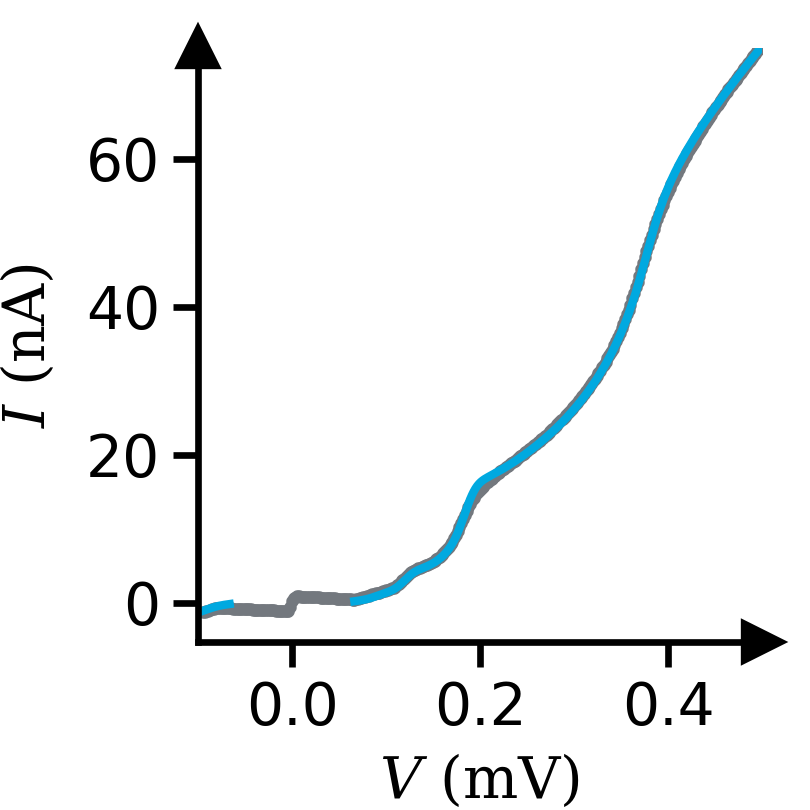

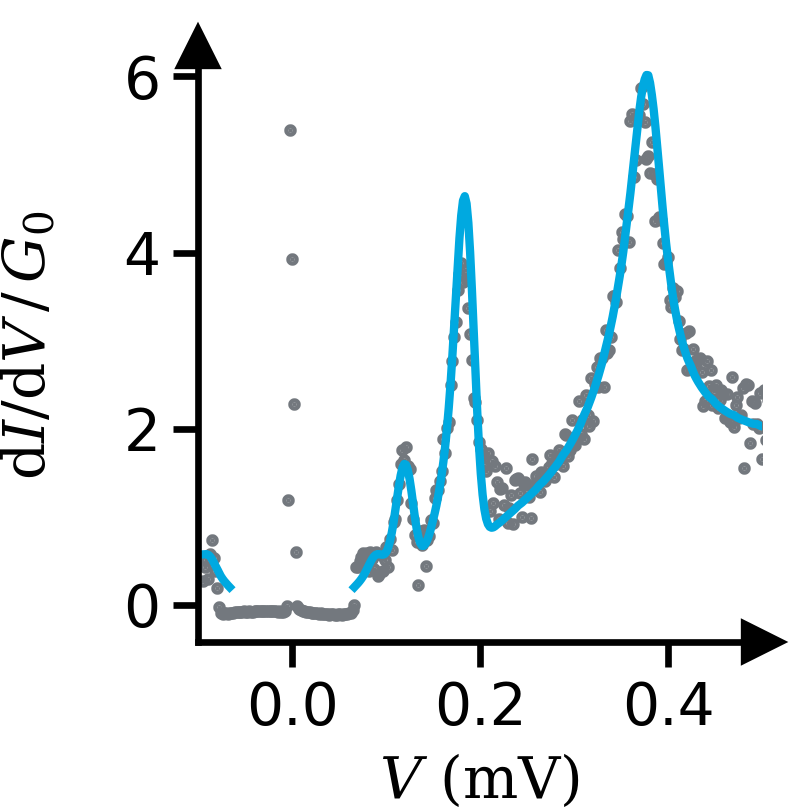

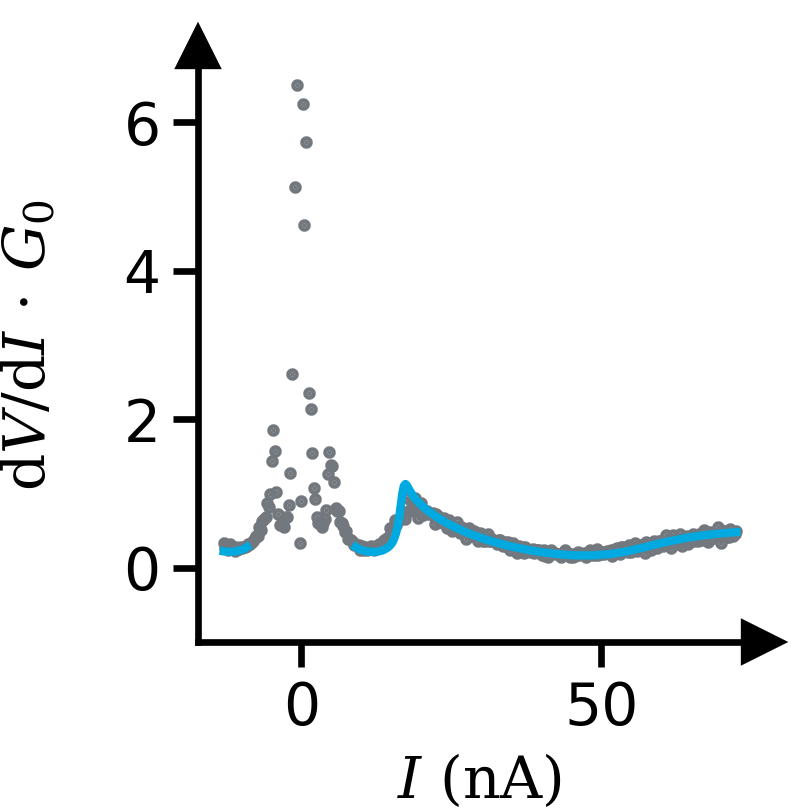

In [ ]:
# fit mar
from superconductivity.utilities.functions.upsampling import upsample

path = "1.8G0/15.0GHz_stripline"
# data_exp = np.load(f"{path}/eva.npz")

# Vbias_mV = data_exp["Vbias_mV"]
# Ibias_nA = data_exp["Ibias_nA"]
# Iexp_nA = data_exp["Iexp_nA"][0, :]
# dGexp_G0 = data_exp["dGexp_G0"][0, :]
# dRexp_R0 = data_exp["dRexp_R0"][0, :]

# data_mar = np.load(f"{path}/mar_data.npz")
# Vbiasmar_mV = data_mar["V_mV"]
# Imar_nA = data_mar["Ifit_nA"]

# data_sc = np.load(f"{path}/sc_data.npz")
# Vbiassc_mV = data_sc["Vbias_mV"]
# Isc_nA = data_sc["Ifit_nA"]


data_sim = np.load(f"{path}/sim.npz")
Delta_meV = data_sim["Delta_meV"]
GN_G0 = data_sim["GN_G0"]

Vbias_mV = data_sim["Vbias"] * Delta_meV
Ibias_nA = data_sim["Vbias"] * Delta_meV * GN_G0 * sc.G0_muS

Iexp_nA = data_sim["Iexp"][0, :] * Delta_meV * GN_G0 * sc.G0_muS
Ipamar_nA = data_sim["Ipamar"][0, :] * Delta_meV * GN_G0 * sc.G0_muS
Iicpt_nA = data_sim["Iicpt"][0, :] * Delta_meV * GN_G0 * sc.G0_muS
Isim_nA = data_sim["Isim"][0, :] * Delta_meV * GN_G0 * sc.G0_muS

dGexp_G0 = data_sim["dGexp"][0, :] * GN_G0
dGpamar_G0 = data_sim["dGpamar"][0, :] * GN_G0
dGicpt_G0 = data_sim["dGicpt"][0, :] * GN_G0
dGsim_G0 = data_sim["dGsim"][0, :] * GN_G0

dRexp_R0 = data_sim["dRexp"][0, :] / GN_G0
dRpamar_R0 = data_sim["dRpamar"][0, :] / GN_G0
dRicpt_R0 = data_sim["dRicpt"][0, :] / GN_G0
dRsim_R0 = data_sim["dRsim"][0, :] / GN_G0

Vexp_mV = data_sim["Vexp"][0, :] * Delta_meV
Vpamar_mV = data_sim["Vpamar"][0, :] * Delta_meV
Vicpt_mV = data_sim["Vicpt"][0, :] * Delta_meV
Vsim_mV = data_sim["Vsim"][0, :] * Delta_meV

Vnan_mV = (-0.065, 0.065)
mask = np.select(
    [
        np.logical_and(Vbias_mV >= Vnan_mV[0], Vbias_mV <= Vnan_mV[1]),
        np.abs(Vbias_mV) >= 0.54,
    ],
    [np.nan, np.nan],
    np.full_like(Vbias_mV, 1.0),
)

fig, ax = sc.get_figure(figsize=(1.35, 1.35), padding=(0.25, 0.2))
ax.plot(Vbias_mV, Iexp_nA, ".", color=sc.seegrau100, ms=1.0)
ax.plot(Vbias_mV * mask, Ipamar_nA * mask, "-", color=sc.seeblau100)
ax.set_yticks([0, 20, 40, 60])
ax.set_ylim(None, 75)
ax.set_xticks([0, 0.2, 0.4])
ax.set_xlim(-0.1, 0.5)
sc.theory_layout(
    fig,
    ax,
    f"atomic_contact/{path}/mar_fit/iv",
    "$V\\ \\mathrm{(mV)}$",
    "$I\\ \\mathrm{(nA)}$",
)
plt.show()

fig, ax = sc.get_figure(figsize=(1.35, 1.35), padding=(0.25, 0.2))
ax.plot(Vbias_mV, dGexp_G0, ".", color=sc.seegrau100, ms=1.0)
ax.plot(Vbias_mV * mask, dGpamar_G0 * mask, "-", color=sc.seeblau100)
ax.set_xticks([0, 0.2, 0.4])
ax.set_xlim(-0.1, 0.5)
sc.theory_layout(
    fig,
    ax,
    f"atomic_contact/{path}/mar_fit/didv",
    "$V\\ \\mathrm{(mV)}$",
    "$\\mathrm{d}I/\\mathrm{d}V\\,/\\,G_0$",
)
plt.show()

fig, ax = sc.get_figure(figsize=(1.35, 1.35), padding=(0.25, 0.2))
ax.plot(Ibias_nA, dRexp_R0, ".", color=sc.seegrau100, ms=1.0)
ax.plot(Ibias_nA * mask, dRpamar_R0 * mask, "-", color=sc.seeblau100)
ax.set_ylim(-1, 7)
sc.theory_layout(
    fig,
    ax,
    f"atomic_contact/{path}/mar_fit/dvdi",
    "$I\\ \\mathrm{(nA)}$",
    "$\\mathrm{d}V/\\mathrm{d}I\\,\\cdot\\,G_0$",
)
plt.show()

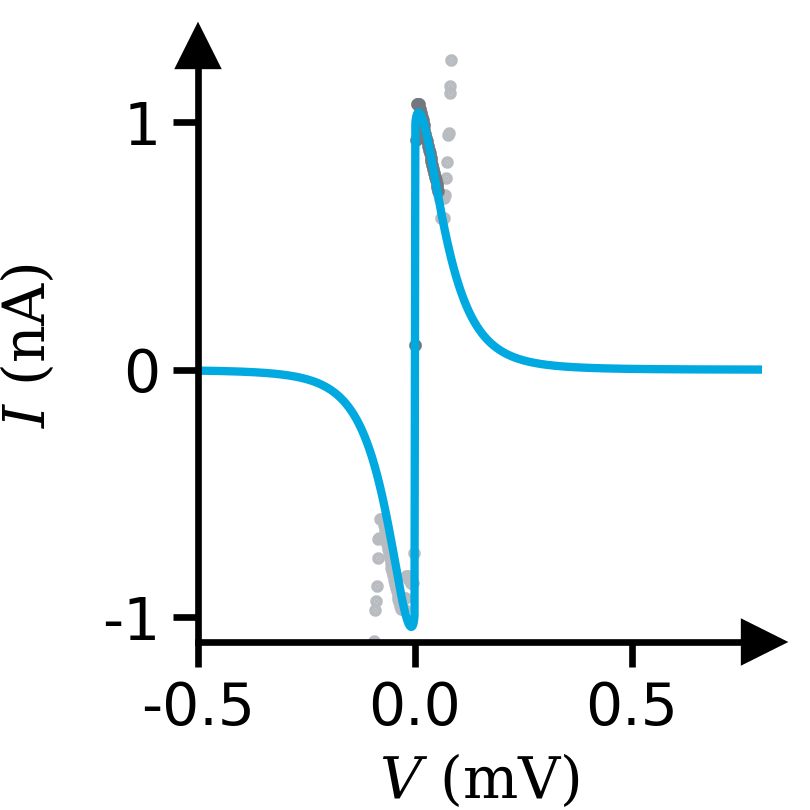

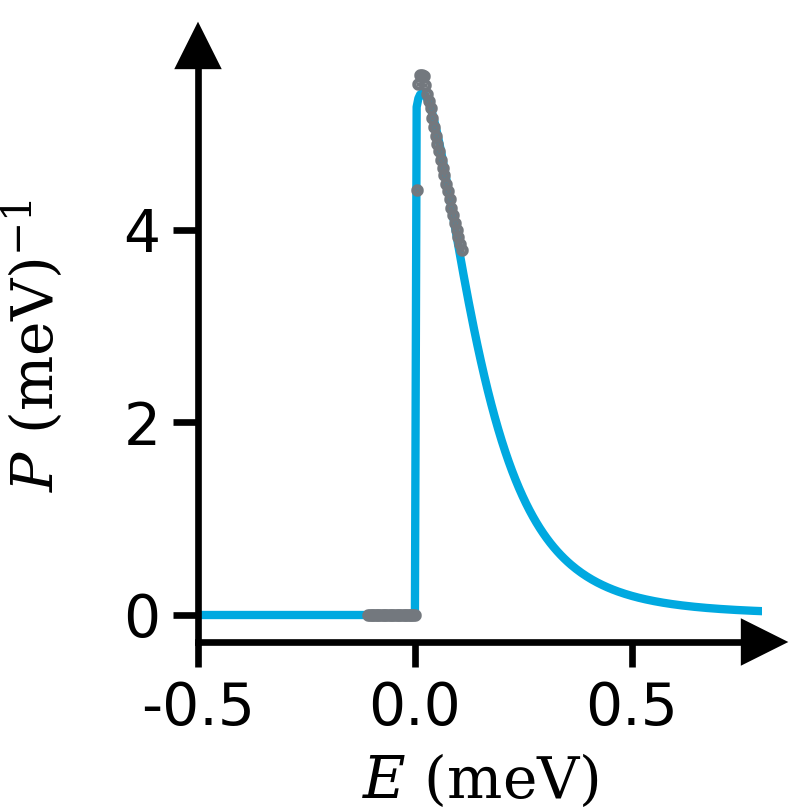

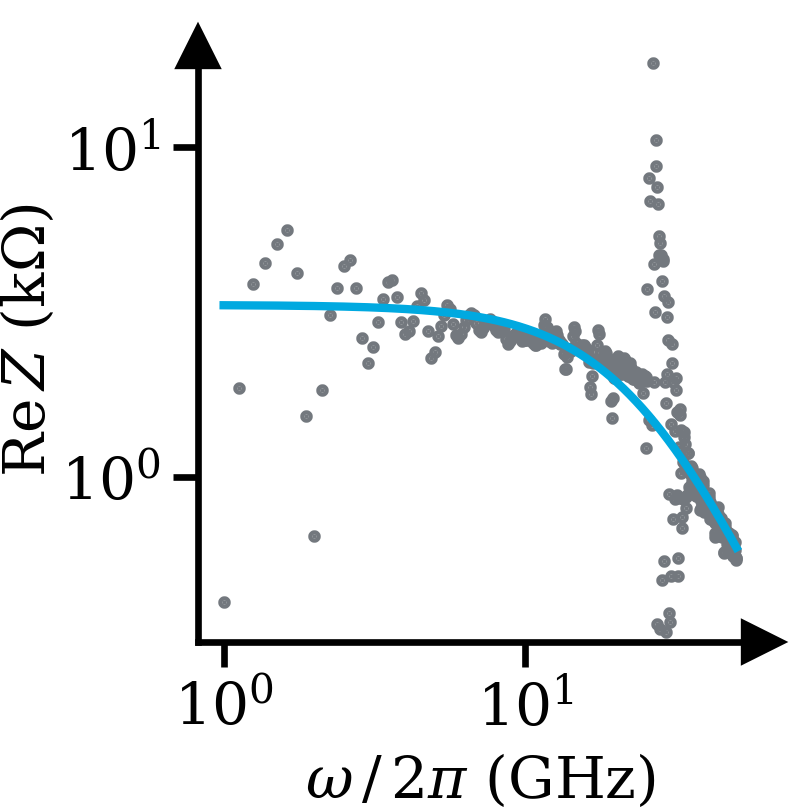

In [ ]:
# fit sc
path = "1.8G0/15.0GHz_stripline"
data = np.load(f"{path}/sc_data.npz")
Vexp_mV = data["Vexp_mV"]
Iexp_nA = data["Iexp_nA"]
Vexp0_mV = data["Vexp0_mV"]
Iexp0_nA = data["Iexp0_nA"]
Vfit_mV = data["Vfit_mV"]
Ifit_nA = data["Ifit_nA"]
mask = data["mask"]
Reff_kOhm = data["Reff_kOhm"]
uReff_kOhm = data["uReff_kOhm"]
Ceff_fF = data["Ceff_fF"]
uCeff_fF = data["uCeff_fF"]
Ic_nA = data["Ic_nA"]
uIc_nA = data["uIc_nA"]
Eexp_ueV = data["Eexp_ueV"]
Pexp__ueV = data["Pexp__ueV"]
Efit_ueV = data["Efit_ueV"]
Pfit__ueV = data["Pfit__ueV"]
nu_GHz = data["nu_GHz"]
Zexp_kOhm = data["Zexp_kOhm"]
Zfit_kOhm = data["Zfit_kOhm"]

fig, ax = sc.get_figure(figsize=(1.35, 1.35), padding=(0.25, 0.2))
ax.plot(Vexp0_mV, Iexp0_nA, ".", color=sc.seegrau35, ms=1.0)
ax.plot(Vexp_mV, Iexp_nA, ".", color=sc.seegrau100, ms=1.0)
ax.plot(Vfit_mV, Ifit_nA, "-", color=sc.seeblau100)
ax.set_xlim(-0.5, 0.8)
ax.set_ylim(-1.1, 1.3)
ax.set_yticks([-1, 0, 1])
# ax.set_ylim(-2.1, 2.3)
# ax.set_xticks([0, 0.2, 0.4])
# ax.set_xlim(-0.08, 0.08)
sc.theory_layout(
    fig,
    ax,
    f"atomic_contact/{path}/sc_fit/iv",
    "$V\\ (\\mathrm{mV})$",
    "$I\\ (\\mathrm{nA})$",
)
plt.show()

fig, ax = sc.get_figure(figsize=(1.35, 1.35), padding=(0.25, 0.2))
ax.plot(Efit_ueV * 1e-3, Pfit__ueV * 1e3, "-", color=sc.seeblau100)
ax.plot(Eexp_ueV * 1e-3, Pexp__ueV * 1e3, ".", color=sc.seegrau100, ms=1.0)
ax.set_xlim(-0.5, 0.8)
sc.theory_layout(
    fig,
    ax,
    f"atomic_contact/{path}/sc_fit/PE",
    "$E\\ (\\mathrm{meV})$",
    "$P\\ (\\mathrm{meV})^{-1}$",
)
plt.show()

fig, ax = sc.get_figure(figsize=(1.35, 1.35), padding=(0.25, 0.2))
mask = (nu_GHz >= 0.9) & (nu_GHz <= 50.0)
ax.plot(
    np.log10(nu_GHz[mask]),
    np.log10(np.abs(np.real(Zexp_kOhm[mask]))),
    ".",
    color=sc.seegrau100,
    ms=1.0,
)
ax.plot(
    np.log10(nu_GHz[mask]), np.log10(np.real(Zfit_kOhm[mask])), "-", color=sc.seeblau100
)
# ax.plot(Efit_ueV, Pfit__ueV, "-", color=sc.seeblau100)
ax.set_ylim(-0.5, 1.3)
ax.set_yticks([0, 1], labels=["$10^0$", "$10^1$"])
ax.set_xticks([0, 1], labels=["$10^0$", "$10^1$"])
sc.theory_layout(
    fig,
    ax,
    f"atomic_contact/{path}/sc_fit/Zv",
    "$\\omega\\,/\\,2\\pi\\ \\mathrm{(GHz)}$",
    "$\\,\\mathrm{Re}\,Z\\ \\mathrm{(k\\Omega)}$",
)
plt.show()

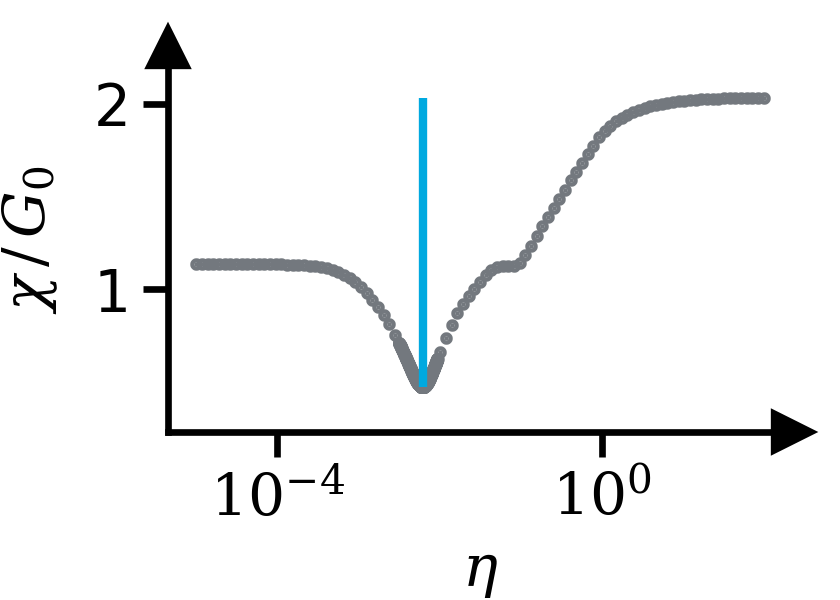

In [40]:
# fit eta
path = "1.8G0/15.0GHz_stripline"
data = np.load(f"{path}/eta_data.npz")
eta = data["eta"]
etas = data["etas"]
chi = data["chi"]
chis = np.sqrt(data["chis"])

fig, ax = sc.get_figure(figsize=(1.4, 1.0), padding=(0.2, 0.2))
ax.plot(np.log10(etas), chis, ".", color=sc.seegrau100, ms=1.0)
ax.vlines(np.log10(eta), np.min(chis), np.max(chis), color=sc.seeblau100)
ax.set_xticks([-4, 0], labels=["$10^{-4}$", "$10^{0}$"])
ax.set_yticks([1, 2])
ax.set_ylim(0.23, 2.3)
sc.theory_layout(
    fig,
    ax,
    f"atomic_contact/{path}/eta_fit",
    "$\\eta$",
    "$\\chi\\,/\\,G_0$",
)
plt.show()

## Calibrated transport landscape

The axes are normalized by $G_N\Delta$, $h\nu$, and the fitted line attenuation $\eta$.

In [ ]:
data_eva = np.load(f"{path}/eva.npz")
data_eta = np.load(f"{path}/eta_data.npz")
data_sim = np.load(f"{path}/sim.npz")

GN_G0 = float(data_sim["GN_G0"])
Delta_meV = float(data_sim["Delta_meV"])
nu_GHz = float(data_eta["nu_GHz"])
eta = float(data_eta["eta"])

Vbias = data_sim["Vbias"]
Ibias = Vbias.copy()
Abias = eta * data_eva["Aout_mV"] / (sc.h_pVs * nu_GHz)

Vbias_mV = Vbias * Delta_meV
Ibias_nA = Ibias * GN_G0 * sc.G0_muS * Delta_meV
Veva_mV = upsample(data_eva["Vbias_mV"])
Ieva_nA = upsample(data_eva["Iexp_nA"])
dGeva_G0 = upsample(data_eva["dGexp_G0"])

Iexp_nA = sc.bin_y_over_x(Ieva_nA, Veva_mV, Vbias_mV)
Vexp_mV = sc.bin_y_over_x(Veva_mV, Ieva_nA, Ibias_nA)
dGexp_G0 = sc.bin_y_over_x(dGeva_G0, Veva_mV, Vbias_mV)

Iexp = Iexp_nA / (GN_G0 * sc.G0_muS * Delta_meV)
dGexp = dGexp_G0 / GN_G0
dRexp = np.gradient(Vexp_mV / Delta_meV, Ibias, axis=-1)

exports = export_amplitude_maps_thesis(
    Vbias=Vbias,
    Abias=Abias,
    Ibias=Ibias,
    Iexp=Iexp,
    dGexp=dGexp,
    dRexp=dRexp,
    waterfall_traces=[0, 2, 4, 6],
    Vbiaslim=(-0.5, 2.8),
    Ibiaslim=(-0.5, 2.8),
    Abiaslim=(0, 7.1),
    Ilim=(-0.5, 3.1),
    dGlim=(-0.1, 3.1),
    dRlim=(-0.1, 4.5),
    Abiasticks=[0, 2, 4, 6],
    surface_x_oversample=1,
    surface_bins=(22, 251),
    name="cal",
    sub_dir=f"atomic_contact/{path}/",
)